C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.7224 - loss: 0.5343 - val_accuracy: 0.7975 - val_loss: 0.4466
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8615 - loss: 0.3308 - val_accuracy: 0.8312 - val_loss: 0.3852
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8926 - loss: 0.2603 - val_accuracy: 0.8369 - val_loss: 0.4022
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9175 - loss: 0.2040 - val_accuracy: 0.8128 - val_loss: 0.4708
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9310 - loss: 0.1776 - val_accuracy: 0.8182 - val_loss: 0.5145
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8182 - loss: 0.5145
Test Accuracy: 0.8181599974632263


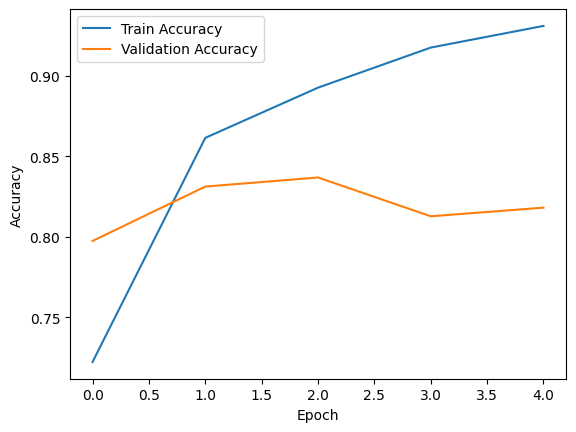

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Negative Review


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

# Pad Sequences
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

# Build RNN Model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    SimpleRNN(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Sample Prediction
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

In [3]:
word_index = tf.keras.datasets.imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        if word in word_index:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown word

    return pad_sequences([encoded], maxlen=100)
sample=encode_review("worst movie")
pred=model.predict(sample)
if pred>0.5:
    print("Positive")
else:
    print("negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
negative
